# Построение модели

## Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from collections import Counter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_id = '1xYULbB7GTlw3oAgk0_qBNlC6gPseBIGt'
url = f'https://drive.google.com/uc?id={file_id}'
output = '2026-04-21_17-05-52_e6g6o9r_merged_dataframe.csv'

if not os.path.exists(output):
    print("Скачиваем...")
    gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
print(f"Строк: {len(df)}, колонок: {len(df.columns)}")
print(f"course_ended есть: {'course_ended' in df.columns}")
print(f"target есть: {'target' in df.columns}")

if 'course_ended' in df.columns:
    print(f"course_ended: {df['course_ended'].value_counts()}")
if 'target' in df.columns:
    print(f"target:{df['target'].value_counts()}")

Скачиваем...


Downloading...
From: https://drive.google.com/uc?id=1xYULbB7GTlw3oAgk0_qBNlC6gPseBIGt
To: /content/2026-04-21_17-05-52_e6g6o9r_merged_dataframe.csv
100%|██████████| 103M/103M [00:00<00:00, 120MB/s]


Строк: 267206, колонок: 100
course_ended есть: True
target есть: True
course_ended: course_ended
0    203284
1     63922
Name: count, dtype: int64
target:target
0    263300
1      3906
Name: count, dtype: int64


## Работа с данными

In [3]:
df = df[df['course_ended'] == 1]

df['target'].unique()

array([0, 1])

Ошибок нет.

In [4]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

target
0    63453
1      469
Name: count, dtype: int64
target
0    0.993
1    0.007
Name: proportion, dtype: float64


Соотношение: 0.77% успешных пар против 99.33% неуспешных.

In [5]:
# Количество уникальных пар user_id + course_id
unique_pairs = df[['user_id', 'course_id']].drop_duplicates().shape[0]

# Количество строк в df
total_rows = len(df)

print(f"Уникальных пар (user_id, course_id): {unique_pairs}")
print(f"Строк в df: {total_rows}")
print(f"Совпадают: {unique_pairs == total_rows}")

Уникальных пар (user_id, course_id): 63922
Строк в df: 63922
Совпадают: True


Убеждаемся - ошибок нет.

In [6]:
user_stats = df.groupby('user_id')['target'].agg(['nunique', 'count'])
mixed = user_stats[user_stats['nunique'] > 1]

print(f"Всего студентов: {len(user_stats)}")
print(f"С разными target: {len(mixed)} ({len(mixed)/len(user_stats)*100:.1f}%)")
print(f"С одним target: {len(user_stats) - len(mixed)}")

Всего студентов: 30933
С разными target: 3 (0.0%)
С одним target: 30930


Подавляющее большинство студентов ведут себя одинаково на всех курсах - либо всегда успешны, либо всегда неуспешны.

Только 3 студента (!) имеет разный target на разных курсах (например, на одном курсе завершил, на другом - нет).

Неуспешные студенты записываются на много курсов и на всех неуспешны, что раздувает количество пар с target=0.

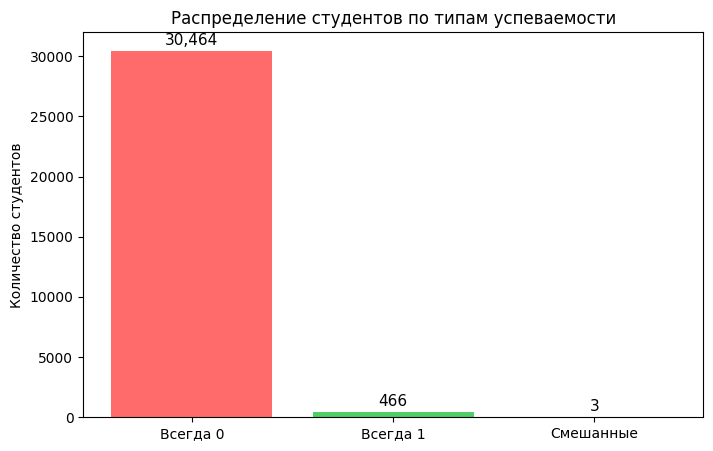

In [7]:
# Считаем типы студентов
user_stats = df.groupby('user_id')['target'].agg(['mean', 'nunique'])
user_stats['type'] = 0
user_stats.loc[user_stats['mean'] == 1, 'type'] = 1
user_stats.loc[(user_stats['mean'] > 0) & (user_stats['mean'] < 1), 'type'] = 2

# Данные для графика
counts = user_stats['type'].value_counts().sort_index()
labels = ['Всегда 0', 'Всегда 1', 'Смешанные']
colors = ['#ff6b6b', '#51cf66', '#ffd43b']

# Бар чарт
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=colors)
plt.title('Распределение студентов по типам успеваемости')
plt.ylabel('Количество студентов')

# Подписи на столбцах
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,}', ha='center', fontsize=11)

plt.show()

In [8]:
# Создаем датафрейм, где одна строка = один студент
df_student = df.groupby('user_id')['target'].max().reset_index()
df_student['target'] = df_student['target'].astype(int)

print(f"Студентов: {len(df_student)}")
print(f"Успешных: {df_student['target'].sum()} ({df_student['target'].mean():.1%})")

Студентов: 30933
Успешных: 469 (1.5%)


### Инсайт и борьба с дисбалансом

Что же мы видим?

Я посмотрел на распределение таргета.

Что у нас для пар студент-курс есть строки с различными типами таргета (0 и 1 на разных курсах, то есть на некоторых студент успешен, а на других нет).

Если мы говорим про пары студент-курс, то он экстремальный.

Модель будет предсказывать 0 для всех и получит Accuracy 99%, но не найдет ни одного успешного студента.

Попробуем копнуть глубже.

Если спуститься до уровня конкретного студента из смешанных примеров - студент Вася, например.

Вася записался на 3 курса. На двух он успешен, но на третьем - нет.

Что тогда будет видеть модель?

Для Васи target бывает и 0, и 1.

Какой в этой ситуации дисбаланс?

Если оставить данные как есть (на уровне пар), то возникает когнитивный диссонанс у алгоритма:

Алгоритм видит Васю на Курсе 1 с действиями [SOLVED, SOLVED] и меткой 1.

Потом он видит того же Васю на Курсе 2 с действиями [FAILED, FAILED] и меткой 0.

Алгоритм думает: "-Окей, если я вижу действия [FAILED, FAILED] и user_id = Вася, какой ответ правильный? В прошлый раз Вася был 1, а сейчас он 0. Что же делать?"

Это уже не дисбаланс классов, это противоречие в данных.

!!! Если дисбаланс личится взвешиванием классов, то противоречие в данных никак не лечится.

Поэтому было принято решение **изменить тип задачи** - и она будет звучать так:

### **Предсказать, является ли студент успешным в принципе (завершит ли он хотя бы один курс), основываясь на его действиях на платформе.**

Таким образом, пожертвовав точностью предсказания для 0.7% смешанных студентов, мы добиваемся:

1. Полного устранения противоречий в целевой переменной (каждому user_id соответствует ровно одна метка: 1 (хотя бы раз сдал) или 0 (никогда не сдавал)).

2. Снижения "шумности" выборки на порядок (мы перестаем кормить модель одним и тем же студентом по 3-10 раз. Данные становятся независимыми и одинаково распределенными (i.i.d.), что является базовым требованием для корректной работы большинства алгоритмов).

3. Перехода от нерешаемой задачи к решаемой (с дисбалансом и противоречиями модель могла только гадать).

In [9]:
df.columns

Index(['id_uc', 'user_id', 'course_id', 'state', 'created_at_uc', 'updated_at',
       'access_finished_at', 'wk_points', 'wk_max_points',
       'wk_max_viewable_lessons', 'wk_max_task_count',
       'wk_officially_started_at', 'wk_course_completed_at', 'flag_inactive',
       'flag_zero_max_points_with_positive_points', 'target', 'target_no_web',
       'target_crit_4_6', 'course_ended', 'id_u', 'created_at_u',
       'sign_in_count', 'with_school', 'timezone_group', 'ut_total_cnt',
       'ut_checked_pct', 'ut_mark_mean', 'ut_mark_ge4_pct', 'ut_points_mean',
       'ut_solved_tasks_mean', 'ut_duration_mean', 'mvs_sessions_cnt',
       'mvs_segments_total_sum', 'mvs_segments_viewed_sum',
       'mvs_segments_viewed_mean', 'mvs_depth_mean', 'mvs_live_cnt',
       'mvs_vod_cnt', 'mvs_kinescope_cnt', 'ul_lessons_cnt',
       'ul_video_visited_pct', 'ul_translation_visited_pct', 'ul_solved_pct',
       'ul_solved_tasks_sum', 'ul_solved_tasks_mean', 'ul_wk_points_sum',
       'ul_wk_point

In [10]:
df.describe()

,id_uc,user_id,course_id,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,flag_inactive,flag_zero_max_points_with_positive_points,target,...,u_peak_dayofweek,u_unique_days,u_actions_per_day,u_mvs_sessions,u_mvs_viewed_total,u_mvs_segments_total,u_mvs_depth_mean,u_mvs_live_pct,u_mvs_vod_pct,u_mvs_kinescope_pct
count,63922.000000,63922.000000,6.392200e+04,63922.000000,63922.000000,63922.000000,63922.000000,63922.000000,63922.000000,63922.000000,...,63467.000000,63467.000000,63467.000000,40332.000000,40332.000000,40332.000000,40332.000000,40332.000000,40332.000000,40332.000000
mean,522206.601467,695312.984199,8.518487e+06,42.630395,73.709239,13.519837,75.533838,0.004114,0.000110,0.007337,...,2.488931,4.223407,5.921284,9.670758,70.204131,101.138624,0.597416,0.003869,0.124726,0.871405
std,33389.454247,14773.779464,3.177260e+07,41.150835,81.083446,6.207394,81.942785,0.064012,0.010464,0.085343,...,1.830024,3.034869,3.816944,8.583640,84.217863,130.258248,0.330582,0.043039,0.259309,0.268575
min,449128.000000,665791.000000,7.630000e+02,0.050000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.021141,0.000000,0.000000,0.000000
25%,495174.250000,683513.500000,7.700000e+02,9.580000,62.000000,14.000000,62.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,3.400000,2.000000,7.000000,20.000000,0.233333,0.000000,0.000000,0.888889
50%,523451.500000,692551.500000,7.700000e+02,47.050000,62.000000,14.000000,62.000000,0.000000,0.000000,0.000000,...,2.000000,3.000000,5.000000,7.000000,38.000000,70.000000,0.681818,0.000000,0.000000,1.000000
75%,548690.250000,708374.750000,7.720000e+02,56.080000,64.000000,14.000000,64.000000,0.000000,0.000000,0.000000,...,4.000000,5.000000,7.500000,15.000000,108.000000,147.000000,0.900000,0.000000,0.111111,1.000000
max,734131.000000,758493.000000,1.700007e+08,492.080000,1230.000000,80.000000,1230.000000,1.000000,1.000000,1.000000,...,6.000000,38.000000,71.000000,77.000000,1034.000000,3603.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
# 1. ДЕМОГРАФИЯ (берём первое значение - они не меняются)
demo_cols = ['with_school', 'timezone_group', 'u_days_since_reg']

# 2. СУММАРНЫЕ ПРИЗНАКИ (сколько всего набрал/сделал)
sum_cols = [
    'wk_points', 'wk_max_points', 'sign_in_count',
    'ut_total_cnt', 'ul_solved_tasks_sum', 'ul_wk_points_sum',
    'mvs_sessions_cnt', 'mvs_segments_total_sum', 'mvs_segments_viewed_sum',
    'mvs_live_cnt', 'mvs_vod_cnt', 'mvs_kinescope_cnt',
    'ul_lessons_cnt', 'u_badges_cnt', 'u_prev_courses_cnt'
]

# 3. СРЕДНИЕ ПРИЗНАКИ (усредняем по курсам)
mean_cols = [
    'ut_checked_pct', 'ut_mark_mean', 'ut_mark_ge4_pct',
    'ut_points_mean', 'ut_solved_tasks_mean', 'ut_duration_mean',
    'mvs_segments_viewed_mean', 'mvs_depth_mean',
    'ul_video_visited_pct', 'ul_translation_visited_pct',
    'ul_solved_pct', 'ul_solved_tasks_mean', 'ul_wk_points_mean',
    'u_prev_progress_mean', 'c_lessons_cnt',
    'c_max_points_per_lesson_mean', 'c_task_count_per_lesson_mean',
    'c_video_duration_mean', 'c_lessons_with_tasks_pct',
    'c_lessons_with_conspect_pct', 'c_total_tasks_cnt',
    'c_required_tasks_cnt', 'c_required_tasks_pct',
    'c_webinars_cnt', 'c_webinar_duration_mean'
]

# 4. МАКСИМАЛЬНЫЕ ПРИЗНАКИ (пиковые достижения)
max_cols = [
    'wk_max_viewable_lessons', 'wk_max_task_count',
    'u_prev_progress_max', 'u_prev_points_mean', 'u_badge_max_id'
]

# 5. ФЛАГИ (если хоть раз было True)
flag_cols = ['flag_inactive', 'flag_zero_max_points_with_positive_points']

In [12]:
# Демография
df_demo = df.groupby('user_id')[demo_cols].first().reset_index()

# Суммы
df_sum = df.groupby('user_id')[sum_cols].sum().reset_index()

# Средние
df_mean = df.groupby('user_id')[mean_cols].mean().reset_index()

# Максимумы
df_max = df.groupby('user_id')[max_cols].max().reset_index()

# Флаги (если хоть раз был 1)
df_flags = df.groupby('user_id')[flag_cols].max().reset_index()

# Объединяем всё
from functools import reduce
dfs_to_merge = [df_demo, df_sum, df_mean, df_max, df_flags]
df_student_features = reduce(lambda left, right: pd.merge(left, right, on='user_id'), dfs_to_merge)

# Добавляем target
df_student = df_student_features.merge(df_student[['user_id', 'target']], on='user_id')

print(f"Итоговый датафрейм: {len(df_student)} студентов, {len(df_student.columns)} признаков")

Итоговый датафрейм: 30933 студентов, 52 признаков


## Проверка признаков на честность

In [13]:
X = df_student.drop(columns=['user_id', 'target'])
y = df_student['target']

# Кодируем категориальные
cat_cols = X.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    X[cat_cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X[cat_cols].fillna('unknown'))

# Заполняем пропуски
X = X.fillna(X.median())

# Считаем AUC для каждого признака
results = []
for col in X.columns:
    auc = cross_val_score(LogisticRegression(class_weight='balanced', max_iter=1000),
                          X[[col]], y, cv=5, scoring='roc_auc').mean()
    results.append({'feature': col, 'auc': round(auc, 4)})

# Таблица
results_df = pd.DataFrame(results).sort_values('auc', ascending=False).reset_index(drop=True)
print(results_df.to_string())

                                      feature     auc
0                      mvs_segments_total_sum  0.9984
1                     mvs_segments_viewed_sum  0.9982
2                     c_webinar_duration_mean  0.9975
3                    mvs_segments_viewed_mean  0.9974
4                              c_webinars_cnt  0.9962
5                                 mvs_vod_cnt  0.9935
6                  ul_translation_visited_pct  0.9447
7                            mvs_sessions_cnt  0.9341
8                                mvs_live_cnt  0.9323
9                            u_days_since_reg  0.9133
10                       c_required_tasks_cnt  0.8693
11                              c_lessons_cnt  0.8636
12                       ul_video_visited_pct  0.8546
13               c_max_points_per_lesson_mean  0.8493
14               c_task_count_per_lesson_mean  0.8493
15                       ul_solved_tasks_mean  0.8439
16                          c_total_tasks_cnt  0.8389
17                          

In [14]:
# Только честные признаки
mask_50_cols = [
    "with_school",
    "timezone_group",
    "u_badges_cnt",
    "u_prev_courses_cnt",
    "u_prev_progress_mean",
    "u_prev_progress_max",
    "u_prev_points_mean",
]

X_honest = X[mask_50_cols].copy()
print(f"Честных признаков: {X_honest.shape[1]}")

# Проверяем
lr_honest = LogisticRegression(class_weight='balanced', max_iter=1000)
auc_honest = cross_val_score(lr_honest, X_honest, y, cv=5, scoring='roc_auc').mean()
print(f"AUC на честных признаках: {auc_honest:.4f}")

Честных признаков: 7
AUC на честных признаках: 0.6029


In [15]:
# Проверяем каждый из 30 признака отдельно
results_honest = []
for col in X_honest.columns:
    auc = cross_val_score(LogisticRegression(class_weight='balanced', max_iter=1000),
                          X_honest[[col]], y, cv=5, scoring='roc_auc').mean()
    results_honest.append({'feature': col, 'auc': round(auc, 4)})

results_honest_df = pd.DataFrame(results_honest).sort_values('auc', ascending=False)
print("Признаки по разделимости")
print(results_honest_df.head(30).to_string(index=False))

Признаки по разделимости
             feature    auc
        u_badges_cnt 0.6224
         with_school 0.5004
u_prev_progress_mean 0.5000
  u_prev_points_mean 0.5000
 u_prev_progress_max 0.5000
  u_prev_courses_cnt 0.4986
      timezone_group 0.4385


In [16]:
# LightGBM с балансировкой
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=5,
    verbose=-1
)

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_auc = cross_val_score(lgb_model, X_honest, y, cv=cv, scoring='roc_auc').mean()

print(f"LightGBM AUC: {lgb_auc:.4f}")

# Обучаем на всех данных и смотрим важность
lgb_model.fit(X_honest, y)
importance = pd.DataFrame({
    'feature': X_honest.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-10 важных признаков")
print(importance.head(10).to_string(index=False))

LightGBM AUC: 0.9369
Топ-10 важных признаков
             feature  importance
        u_badges_cnt         769
      timezone_group         648
  u_prev_courses_cnt          68
         with_school           0
u_prev_progress_mean           0
 u_prev_progress_max           0
  u_prev_points_mean           0


## Результаты моделирования на априорных данных

В рамках эксперимента по исключению утечки данных был сформирован набор признаков, доступных исключительно до момента начала обучения (априорные данные о студенте). В результате строгой фильтрации итоговый датасет содержал 7 независимых переменных, включая демографические характеристики (`timezone_group`), историю взаимодействия с платформой (`u_badges_cnt`, `u_prev_courses_cnt`) и агрегированные показатели предыдущих периодов (`u_prev_progress_*`). Применение градиентного бустинга (LightGBM) позволило достичь значения ROC-AUC на уровне 0.937 на кросс-валидации. Примечательно, что линейные модели (Logistic Regression) на том же наборе данных демонстрировали качество, близкое к случайному (AUC = 0.603), что свидетельствует о наличии сложных нелинейных взаимодействий между априорными признаками.

**Заключение:** Поведенческий паттерн "коллекционера достижений", сформированный до начала курса, является наиболее валидным предиктором успешности обучения.